In [73]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # registers .pl accessor

PROC_DIR = Path("/mnt/scratch2/Chloe/Biohackathon/Dataset_5/sdata.zarr")
sys.path.insert(0, str(PROC_DIR.parent.parent.parent / "src"))

import sys

sys.path.insert(0, "/mnt/scratch2/Chloe/Biohackathon/KIDS26-Team18/src")

from plot import SpatialCoord_plot, custom_barplot, dotplot, plot_umap, set_scanpy_colors

In [74]:
sdata = sd.read_zarr(r"/mnt/scratch2/Chloe/Biohackathon/Dataset_5/sdata.zarr")
adata = sdata["table"]

### **Approach I**

In [76]:
x = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
assert x.min() >= 0, f"Expected nonnegative counts, got min={x.min()}"
assert np.allclose(x.sum(axis=1), adata.obs["transcript_counts"], rtol=1e-4), "X row sums must match nCount"
print(f"X holds integer transcript counts (min={x.min():.0f}, max={x.max():.0f})")
print(f"Row-sum check vs nCount: OK ({adata.n_obs:,} cells)")

X holds integer transcript counts (min=0, max=141)
Row-sum check vs nCount: OK (9,960 cells)


In [77]:
SCANPY_CFG = {
    "n_pcs": 30,
    "n_neighbors": 15,
    "leiden_resolution": 0.5,
    "rank_genes_top_n": 20,
    "seed": 42,
}

adata_sc = adata.copy()

# Targeted 343-gene panel: use all genes (no HVG subset)
sc.pp.normalize_total(adata_sc, target_sum=1e4)
sc.pp.log1p(adata_sc)
sc.pp.scale(adata_sc, max_value=10)

n_comps = min(SCANPY_CFG["n_pcs"], adata_sc.n_obs - 1, adata_sc.n_vars - 1)
sc.tl.pca(adata_sc, n_comps=n_comps, random_state=SCANPY_CFG["seed"])
sc.pp.neighbors(adata_sc, n_neighbors=SCANPY_CFG["n_neighbors"])
sc.tl.leiden(
    adata_sc,
    resolution=SCANPY_CFG["leiden_resolution"],
    key_added="leiden",
    random_state=SCANPY_CFG["seed"],
)
sc.tl.umap(adata_sc, random_state=SCANPY_CFG["seed"])

# Copy results back to adata (single object used throughout)
adata.obs["leiden"] = adata_sc.obs["leiden"].astype(str)
adata.obsm["X_umap"] = adata_sc.obsm["X_umap"]


/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [78]:
adata_sc = adata.copy()
# Targeted 343-gene panel: use all genes (no HVG subset)
sc.pp.normalize_total(adata_sc, target_sum=1e4)
sc.pp.log1p(adata_sc)
sc.tl.rank_genes_groups(adata_sc, groupby="leiden", method="wilcoxon", use_raw=False)
adata.uns["rank_genes_groups"] = adata_sc.uns["rank_genes_groups"]

/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe 

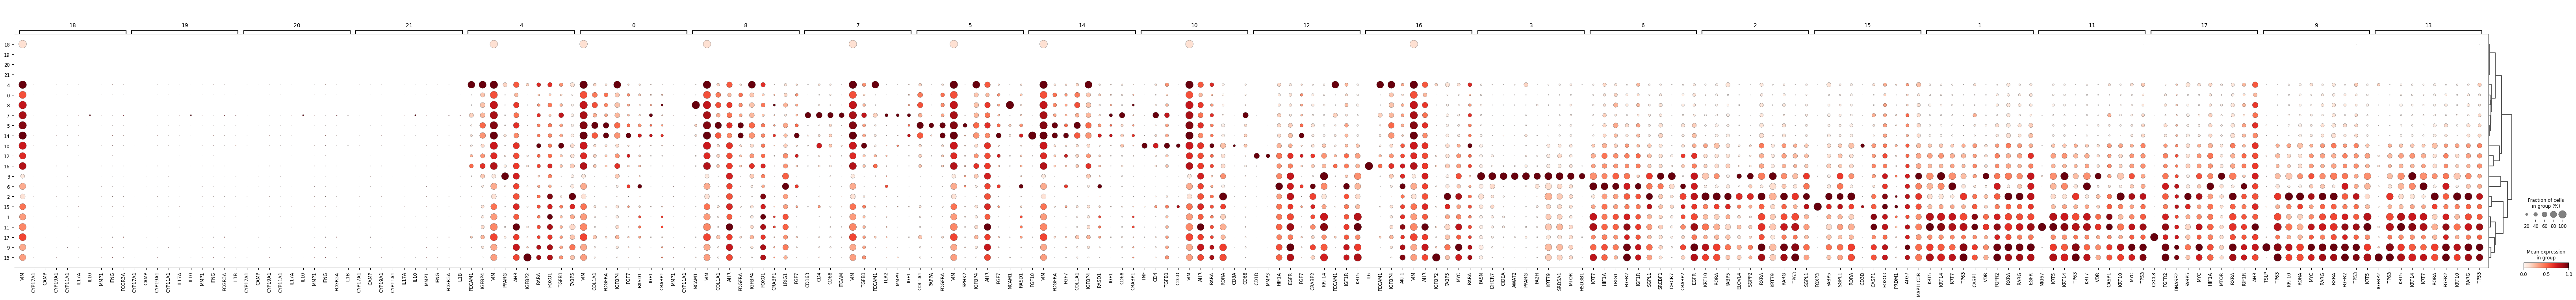

In [80]:
#top_n = SCANPY_CFG["rank_genes_top_n"]
top_n = 10
clusters = sorted(adata.obs["leiden"].unique(), key=lambda x: int(x))

marker_tables = []
for cluster in clusters:
    df = sc.get.rank_genes_groups_df(adata, group=cluster)
    df = df.head(top_n).copy()
    df.insert(0, "cluster", cluster)
    marker_tables.append(df)

markers_top20 = pd.concat(marker_tables, ignore_index=True)

sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=top_n,
    groupby="leiden",
    standard_scale="var",
    show=False,
)
plt.show()

In [81]:
marker_dict = (
    markers_top20
    .groupby("cluster", sort=False)["names"]
    .apply(list)
    .to_dict()
)

marker_dict

{'0': ['VIM',
  'COL1A1',
  'PDGFRA',
  'IGFBP4',
  'FGF7',
  'RASD1',
  'IGF1',
  'CRABP1',
  'MMP1',
  'CYP11A1'],
 '1': ['KRT5',
  'KRT14',
  'KRT7',
  'TP63',
  'CASP1',
  'VDR',
  'FGFR2',
  'RXRA',
  'RARG',
  'EGFR'],
 '2': ['KRT10',
  'RORA',
  'FABP5',
  'ELOVL4',
  'SGPP2',
  'RXRA',
  'KRT79',
  'RARG',
  'TP63',
  'SGPL1'],
 '3': ['FASN',
  'DHCR7',
  'CIDEA',
  'AWAT2',
  'PPARG',
  'FA2H',
  'KRT79',
  'SRD5A1',
  'MTOR',
  'HSD3B1'],
 '4': ['PECAM1',
  'IGFBP4',
  'VIM',
  'PPARG',
  'AHR',
  'IGFBP2',
  'RARA',
  'FOXO1',
  'TGFB1',
  'FABP5'],
 '5': ['COL1A1',
  'PAPPA',
  'PDGFRA',
  'VIM',
  'SPHK2',
  'IGFBP4',
  'AHR',
  'FGF7',
  'NCAM1',
  'RASD1'],
 '6': ['KRT7',
  'HIF1A',
  'LRIG1',
  'FGFR2',
  'IGF1R',
  'SGPL1',
  'SREBF1',
  'DHCR7',
  'CRABP2',
  'EGFR'],
 '7': ['CD163',
  'CD4',
  'CD68',
  'ITGAM',
  'VIM',
  'TGFB1',
  'PECAM1',
  'TLR2',
  'MMP9',
  'IGF1'],
 '8': ['NCAM1',
  'VIM',
  'COL1A1',
  'AHR',
  'PDGFRA',
  'IGFBP4',
  'FOXO1',
  'CRABP1',
 

In [82]:
# Update this dict after reviewing the marker tables above.
# Keys are Leiden cluster IDs (strings). Unmapped clusters become "Unassigned".

CLUSTER_ANNOTATIONS = {

    "0":  "Fibroblast",
    "1":  "Basal keratinocyte",
    "2":  "Differentiating keratinocyte",
    "3":  "Sebocyte",
    "4":  "Endothelial",
    "5":  "Fibroblast",
    "6":  "Basal keratinocyte",
    "7":  "Macrophage",
    "8":  "Fibroblast",
    "9":  "Differentiating keratinocyte",
    "10": "T cell",
    "11": "Cycling keratinocyte",
    "12": "Basal keratinocyte",
    "13": "Basal keratinocyte",
    "14": "Fibroblast",
    "15": "T cell",
    "16": "Endothelial",
    "17": "Inflammatory epithelial",
    "18": "Inflammatory immune",
    "19": "Inflammatory immune",
    "20": "Inflammatory immune",
    "21": "Inflammatory immune",
}

adata.obs["cell_type_scanpy"] = (
    adata.obs["leiden"]
    .astype(str)
    .map(CLUSTER_ANNOTATIONS)
    .fillna("Unassigned")
)

adata.obs["cell_type_scanpy"] = adata.obs["cell_type_scanpy"].astype("category")

display(
    adata.obs["cell_type_scanpy"].value_counts(dropna=False)
)

cell_type_scanpy
Fibroblast                      3079
Basal keratinocyte              2753
Differentiating keratinocyte    1304
Endothelial                      738
Sebocyte                         723
T cell                           434
Macrophage                       433
Cycling keratinocyte             237
Inflammatory immune              156
Inflammatory epithelial          103
Name: count, dtype: int64

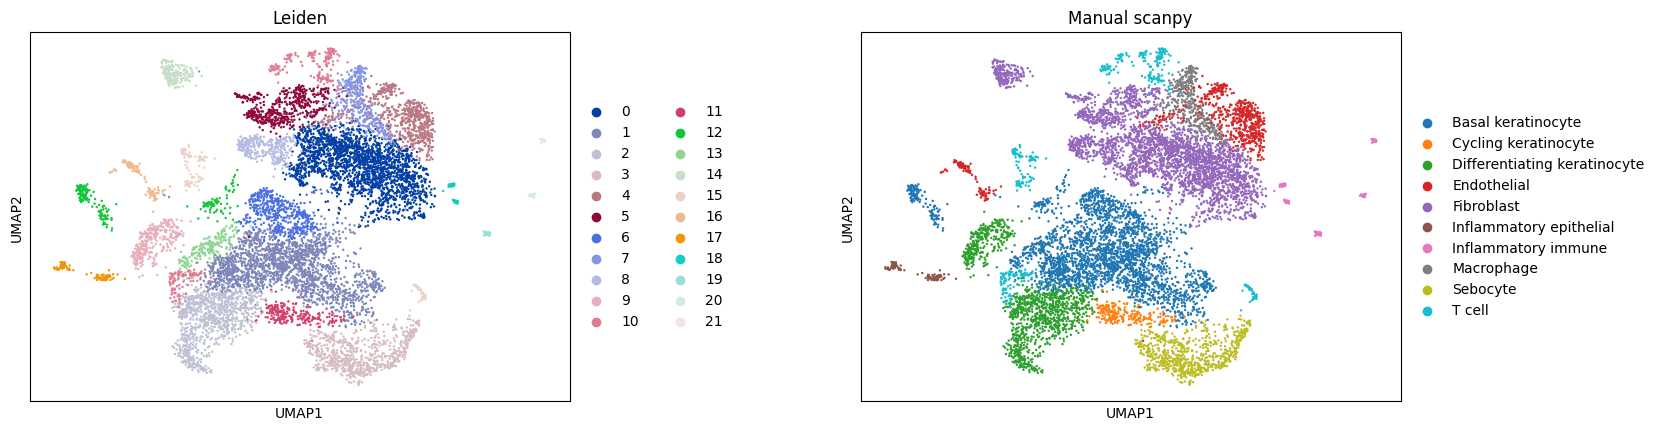

/tmp/ipykernel_602334/1279783087.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


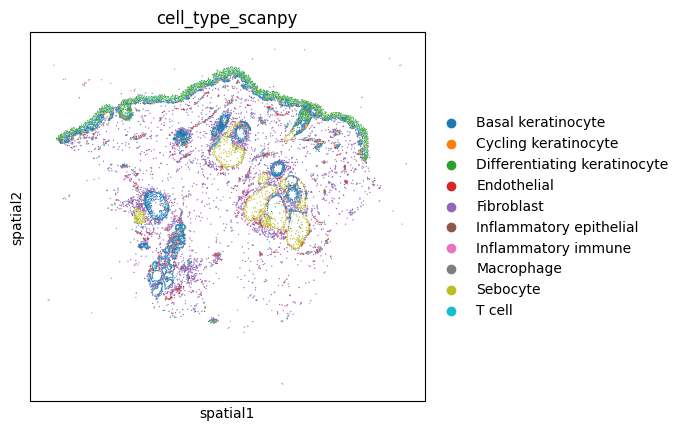

In [83]:
sc.pl.umap(
    adata,
    color=["leiden", "cell_type_scanpy"],
    wspace=0.4,
    title=[f"Leiden", f"Manual scanpy"],
)

sc.pl.spatial(
    adata,
    color="cell_type_scanpy",
    spot_size=10,
)

### **Approach II** 
#### a) Cell-type specific markers

In [84]:
CELL_TYPE_CANDIDATES = {
    "Keratinocyte": [
        "KRT5", "KRT14", "KRT10", "KRT1",
        "KRT15", "KRT17", "KRT7"
    ],

    "Fibroblast": [
        "COL1A1", "COL1A2", "DCN", "LUM",
        "COL3A1", "PDGFRA"
    ],

    "Endothelial": [
        "PECAM1", "VWF", "EMCN", "KDR",
        "ESAM", "ENG"
    ],

    "Sebocyte": [
        "FASN", "PPARG", "CIDEA", "AWAT2",
        "AWAT1", "PLIN2"
    ],

    "Macrophage": [
        "CD68", "CD163", "LYZ", "ITGAM",
        "FCGR3A", "CST3", "TYROBP"
    ],

    "T cell": [
        "CD3D", "CD3E", "TRBC1", "TRBC2",
        "CD4", "CD8A"
    ],

    "Inflammatory immune cell": [
        "IL1B", "TNF", "CXCL8", "FCGR3A",
        "S100A8", "S100A9", "CCL2"
    ],
}

In [85]:
def detection_rate(adata, genes):
    """Fraction of cells with raw count > 0 for each gene."""

    present = [g for g in genes if g in adata.var_names]

    rates = {}

    for gene in present:
        x = adata[:, gene].X

        if hasattr(x, "toarray"):
            x = x.toarray().ravel()
        else:
            x = np.asarray(x).ravel()

        rates[gene] = float((x > 0).mean())

    return pd.Series(rates).sort_values(ascending=False)


CELL_TYPE_MARKERS = {}

for cell_type, candidates in CELL_TYPE_CANDIDATES.items():

    rates = detection_rate(adata, candidates)

    CELL_TYPE_MARKERS[cell_type] = rates.head(4).index.tolist()

    print(f"\n{cell_type}")
    display(rates.head(4))


Keratinocyte


KRT14    0.517871
KRT5     0.514157
KRT7     0.465863
KRT10    0.428614
dtype: float64


Fibroblast


COL1A1    0.295683
PDGFRA    0.198494
dtype: float64


Endothelial


...

CD68      0.128313
CD163     0.050803
ITGAM     0.048494
FCGR3A    0.009739
dtype: float64


T cell


CD4     0.116265
CD3D    0.021185
CD8A    0.011647
dtype: float64


Inflammatory immune cell


TNF       0.028313
CXCL8     0.011647
IL1B      0.010141
FCGR3A    0.009739
dtype: float64

In [86]:
def assign_rule_labels(adata, cell_type_markers):
    """Assign a cell type when all 4 marker genes have raw count > 0."""

    labels = np.full(adata.n_obs, "Unassigned", dtype=object)

    for cell_type, genes in cell_type_markers.items():

        if len(genes) != 4:
            continue

        x = adata[:, genes].X

        if hasattr(x, "toarray"):
            x = x.toarray()

        x = np.asarray(x)

        # All 4 genes must have raw count > 0
        positive = (x > 0).all(axis=1)

        # Only assign cells that haven't already been assigned
        assign = positive & (labels == "Unassigned")

        labels[assign] = cell_type

    return labels


adata.obs["cell_type_rule"] = pd.Categorical(
    assign_rule_labels(adata, CELL_TYPE_MARKERS)
)

display(
    adata.obs["cell_type_rule"].value_counts(dropna=False)
)

cell_type_rule
Unassigned      7178
Keratinocyte    2605
Sebocyte         164
Macrophage        13
Name: count, dtype: int64

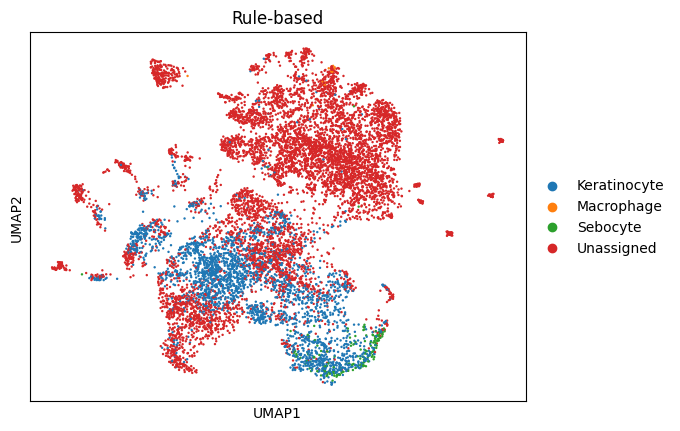

/tmp/ipykernel_602334/4081576922.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


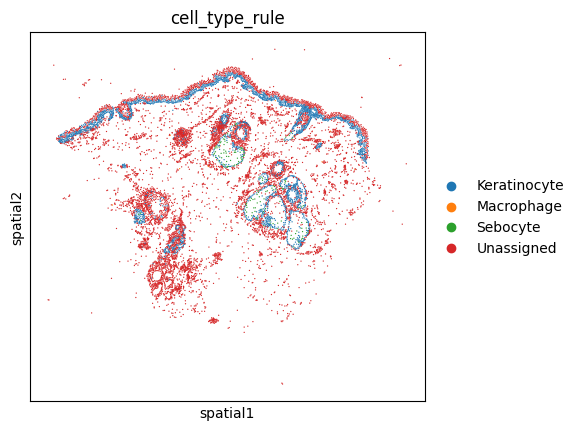

In [87]:
sc.pl.umap(
    adata,
    color="cell_type_rule",
    title=f"Rule-based",
)

sc.pl.spatial(
    adata,
    color="cell_type_rule",
    spot_size=10,
)


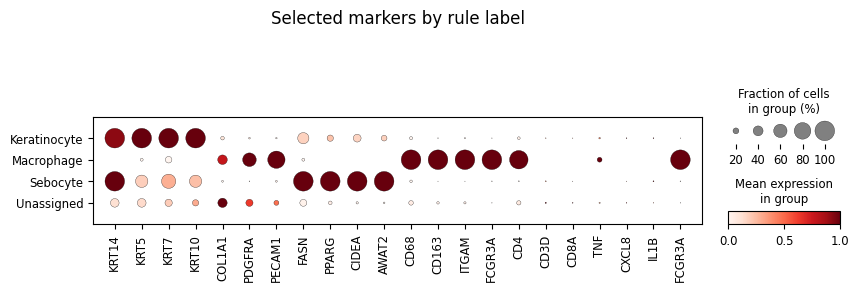

In [88]:
ALL_MARKERS = [
    gene
    for genes in CELL_TYPE_MARKERS.values()
    for gene in genes
]

sc.pl.dotplot(
    adata,
    var_names=ALL_MARKERS,
    groupby="cell_type_rule",
    standard_scale="var",
    title="Selected markers by rule label",
)

In [89]:
print(f"Comparison for sample:\n")

print("=== Counts ===")
summary = pd.DataFrame({
    "cell_type_scanpy": adata.obs["cell_type_scanpy"].value_counts(),
    "cell_type_rule": adata.obs["cell_type_rule"].value_counts(),
})
display(summary)

print("\n=== Crosstab (scanpy rows × rule cols) ===")
ct = pd.crosstab(
    adata.obs["cell_type_scanpy"],
    adata.obs["cell_type_rule"],
    margins=True,
)
display(ct)

print("\n=== Row-normalized crosstab ===")
ct_norm = pd.crosstab(
    adata.obs["cell_type_scanpy"],
    adata.obs["cell_type_rule"],
    normalize="index",
).round(3)
display(ct_norm)

Comparison for sample:

=== Counts ===


,cell_type_scanpy,cell_type_rule
Basal keratinocyte,2753.0,NaN
Cycling keratinocyte,237.0,NaN
Differentiating keratinocyte,1304.0,NaN
Endothelial,738.0,NaN
Fibroblast,3079.0,NaN
Inflammatory epithelial,103.0,NaN
Inflammatory immune,156.0,NaN
Keratinocyte,NaN,2605.0
Macrophage,433.0,13.0
Sebocyte,723.0,164.0



=== Crosstab (scanpy rows × rule cols) ===


cell_type_rule,Keratinocyte,Macrophage,Sebocyte,Unassigned,All
cell_type_scanpy,,,,,
Basal keratinocyte,1313,0,1,1439,2753
Cycling keratinocyte,187,0,0,50,237
Differentiating keratinocyte,431,0,0,873,1304
Endothelial,30,0,1,707,738
Fibroblast,25,1,2,3051,3079
Inflammatory epithelial,29,0,1,73,103
Inflammatory immune,0,0,0,156,156
Macrophage,5,12,0,416,433
Sebocyte,488,0,159,76,723



=== Row-normalized crosstab ===


cell_type_rule,Keratinocyte,Macrophage,Sebocyte,Unassigned
cell_type_scanpy,,,,
Basal keratinocyte,0.477,0.000,0.000,0.523
Cycling keratinocyte,0.789,0.000,0.000,0.211
Differentiating keratinocyte,0.331,0.000,0.000,0.669
Endothelial,0.041,0.000,0.001,0.958
Fibroblast,0.008,0.000,0.001,0.991
Inflammatory epithelial,0.282,0.000,0.010,0.709
Inflammatory immune,0.000,0.000,0.000,1.000
Macrophage,0.012,0.028,0.000,0.961
Sebocyte,0.675,0.000,0.220,0.105


#### b) Working with markers in the dataset

**2 Gene Markers**

In [90]:
skin_markers_2 = {
    "Basal keratinocyte": ["KRT5", "TP63"],
    "Cycling keratinocyte": ["MKI67", "MYC"],
    "Differentiating keratinocyte": ["KRT10", "KRT7"],
    "Endothelial": ["PECAM1", "EGFR"],
    "Fibroblast": ["COL1A1", "PDGFRA"],
    "Inflammatory epithelial": ["KRT14", "CXCL8"],
    "Inflammatory immune": ["ITGAM", "FCGR3A"],
    "Keratinocyte": ["KRT14", "KRT5"],
    "Macrophage": ["CD68", "CD163"],
    "Sebocyte": ["FASN", "DGAT1"],
    "T cell": ["CD3D", "CD4"],
}

In [91]:
def _get_gene_counts(adata, genes):
    """Return (n_cells, n_genes) array of integer transcript counts from .X."""
    x = adata[:, genes].X

    if hasattr(x, "toarray"):
        return x.toarray()

    return np.asarray(x)


def assign_rule_labels(adata, skin_markers_2):
    """Assign a cell type when both markers have count > 0."""
    
    labels = np.full(adata.n_obs, "Unassigned", dtype=object)

    for cell_type, genes in skin_markers_2.items():
        x = _get_gene_counts(adata, genes)

        # Both markers must have count > 0
        positive = (x > 0).all(axis=1)

        # Only assign cells that haven't already been assigned
        labels[positive & (labels == "Unassigned")] = cell_type

    return labels


adata.obs["cell_type_rule_2"] = pd.Categorical(
    assign_rule_labels(adata, skin_markers_2)
)

print(f"Rule-based labels")
display(adata.obs["cell_type_rule_2"].value_counts())

Rule-based labels


cell_type_rule_2
Basal keratinocyte              3906
Unassigned                      3108
Fibroblast                      1348
Differentiating keratinocyte     499
Keratinocyte                     404
Endothelial                      264
Macrophage                       167
Sebocyte                         141
T cell                            63
Cycling keratinocyte              32
Inflammatory epithelial           17
Inflammatory immune               11
Name: count, dtype: int64

**3 Gene Markers**

In [92]:
skin_markers_3 = {
    "Basal keratinocyte": ["KRT5", "KRT14", "TP63"],
    "Cycling keratinocyte": ["MKI67", "MYC", "EGFR"],
    "Differentiating keratinocyte": ["KRT10", "KRT7", "VDR"],
    "Endothelial": ["PECAM1", "EGFR", "VIM"],
    "Fibroblast": ["COL1A1", "PDGFRA", "VIM"],
    "Inflammatory epithelial": ["KRT14", "CXCL8", "IL1B"],
    "Inflammatory immune": ["ITGAM", "FCGR3A", "TNF"],
    "Keratinocyte": ["KRT14", "KRT5", "KRT10"],
    "Macrophage": ["CD68", "CD163", "ITGAM"],
    "Sebocyte": ["FASN", "DGAT1", "PPARG"],
    "T cell": ["CD3D", "CD4", "CD8A"],
}

In [93]:
def _get_gene_counts(adata, genes):
    """Return (n_cells, n_genes) array of transcript counts from .X."""

    genes = [g for g in genes if g in adata.var_names]

    if len(genes) == 0:
        return np.zeros((adata.n_obs, 0))

    x = adata[:, genes].X

    if hasattr(x, "toarray"):
        return x.toarray()

    return np.asarray(x)


def assign_rule_labels(adata, skin_markers_3):
    """Assign a cell type when all marker genes in a panel have count > 0."""

    labels = np.full(adata.n_obs, "Unassigned", dtype=object)

    for cell_type, genes in skin_markers_3.items():

        # Only use genes that are actually present
        genes_present = [g for g in genes if g in adata.var_names]

        if len(genes_present) == 0:
            continue

        x = _get_gene_counts(adata, genes_present)

        # Cell is positive if ALL marker genes are detected
        positive = (x > 0).all(axis=1)

        # Only assign currently unassigned cells
        labels[positive & (labels == "Unassigned")] = cell_type

    return labels


adata.obs["cell_type_rule_3"] = pd.Categorical(
    assign_rule_labels(adata, skin_markers_3)
)

print("Rule-based labels")

display(adata.obs["cell_type_rule_3"].value_counts())

Rule-based labels


cell_type_rule_3
Unassigned                      4015
Basal keratinocyte              3675
Fibroblast                      1383
Endothelial                      273
Differentiating keratinocyte     247
Keratinocyte                     166
Macrophage                       108
Sebocyte                          48
Cycling keratinocyte              34
T cell                             9
Inflammatory immune                2
Name: count, dtype: int64

**4 Gene Markers**

In [95]:
skin_markers_4 = {
    "Basal keratinocyte": ["KRT5", "KRT14", "TP63", "KRT79"],
    "Cycling keratinocyte": ["MKI67", "MYC", "EGFR", "TP63"],
    "Differentiating keratinocyte": ["KRT10", "KRT7", "KRT79", "VDR"],
    "Endothelial": ["PECAM1", "EGFR", "FGF10", "VIM"],
    "Fibroblast": ["COL1A1", "PDGFRA", "VIM", "FGF7"],
    "Inflammatory epithelial": ["KRT14", "CXCL8", "IL1B", "TSLP"],
    "Inflammatory immune": ["ITGAM", "FCGR3A", "IL1B", "TNF"],
    "Keratinocyte": ["KRT14", "KRT5", "KRT10", "KRT7"],
    "Macrophage": ["CD68", "CD163", "ITGAM", "FCGR3A"],
    "Sebocyte": ["FASN", "DGAT1", "PPARG", "SCD"],
    "T cell": ["CD3D", "CD4", "CD8A", "FOXP3"],
}

In [96]:
def _get_gene_counts(adata, genes):
    """Return (n_cells, n_genes) array of integer transcript counts from .X."""
    x = adata[:, genes].X

    if hasattr(x, "toarray"):
        return x.toarray()

    return np.asarray(x)


def assign_rule_labels(adata, skin_markers_4):
    """Assign a cell type when all 4 markers have count > 0."""
    
    labels = np.full(adata.n_obs, "Unassigned", dtype=object)

    for cell_type, genes in skin_markers_4.items():
        x = _get_gene_counts(adata, genes)

        # All 4 markers must have count > 0
        positive = (x > 0).all(axis=1)

        # Only assign cells that haven't already been assigned
        labels[positive & (labels == "Unassigned")] = cell_type

    return labels


adata.obs["cell_type_rule_4"] = pd.Categorical(
    assign_rule_labels(adata, skin_markers_4)
)

print(f"Rule-based labels")
display(adata.obs["cell_type_rule_4"].value_counts())

Rule-based labels


cell_type_rule_4
Unassigned                      5774
Basal keratinocyte              2718
Fibroblast                       573
Keratinocyte                     533
Differentiating keratinocyte     234
Cycling keratinocyte              46
Sebocyte                          46
Endothelial                       21
Macrophage                        12
T cell                             2
Inflammatory immune                1
Name: count, dtype: int64

/tmp/ipykernel_602334/3318487955.py:19: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_602334/3318487955.py:37: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_602334/3318487955.py:55: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


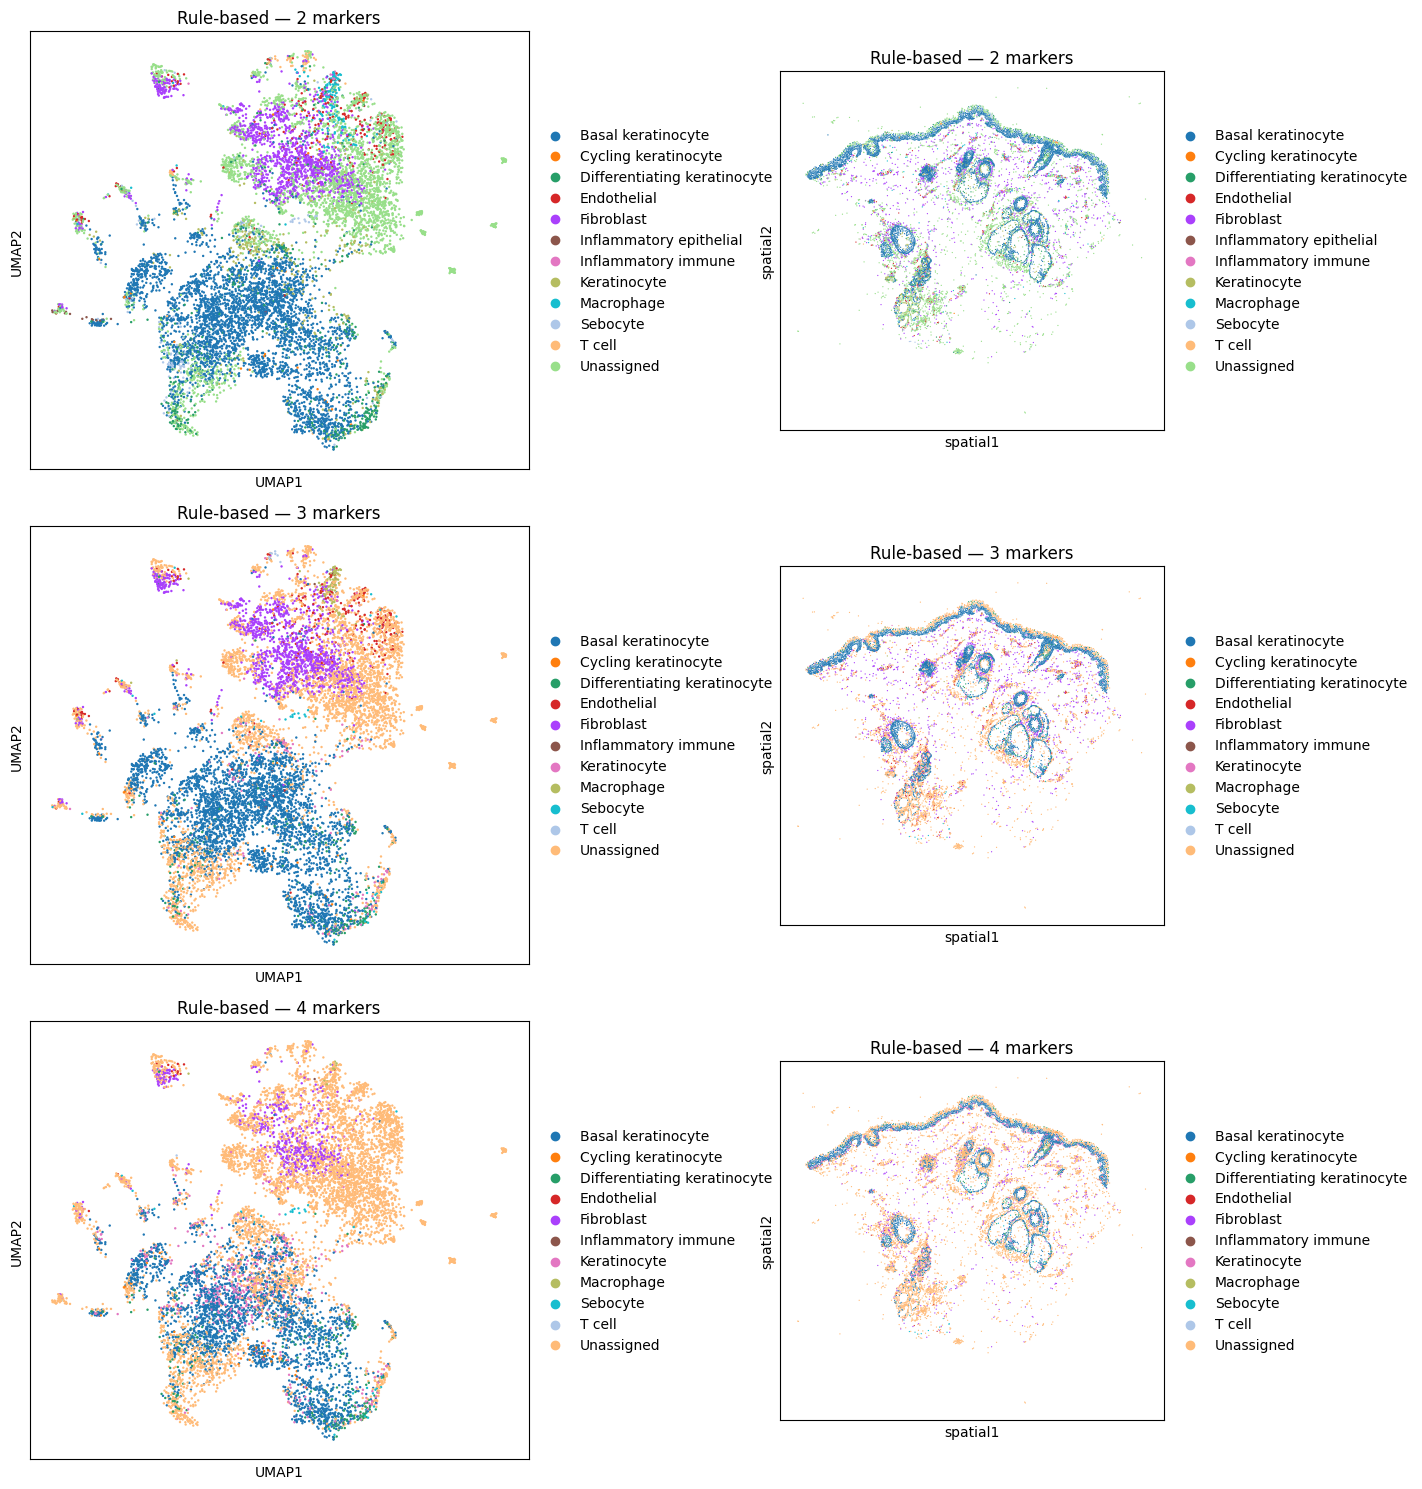

In [97]:
import matplotlib.pyplot as plt
import scanpy as sc

fig, axs = plt.subplots(
    3, 2,
    figsize=(14, 15),
    gridspec_kw={"width_ratios": [1.3, 1]}
)

# Rule 2
sc.pl.umap(
    adata,
    color="cell_type_rule_2",
    title="Rule-based — 2 markers",
    ax=axs[0, 0],
    show=False
)

sc.pl.spatial(
    adata,
    color="cell_type_rule_2",
    spot_size=10,
    title="Rule-based — 2 markers",
    ax=axs[0, 1],
    show=False
)

# Rule 3
sc.pl.umap(
    adata,
    color="cell_type_rule_3",
    title="Rule-based — 3 markers",
    ax=axs[1, 0],
    show=False
)

sc.pl.spatial(
    adata,
    color="cell_type_rule_3",
    spot_size=10,
    title="Rule-based — 3 markers",
    ax=axs[1, 1],
    show=False
)

# Rule 4
sc.pl.umap(
    adata,
    color="cell_type_rule_4",
    title="Rule-based — 4 markers",
    ax=axs[2, 0],
    show=False
)

sc.pl.spatial(
    adata,
    color="cell_type_rule_4",
    spot_size=10,
    title="Rule-based — 4 markers",
    ax=axs[2, 1],
    show=False
)

plt.tight_layout()
plt.show()

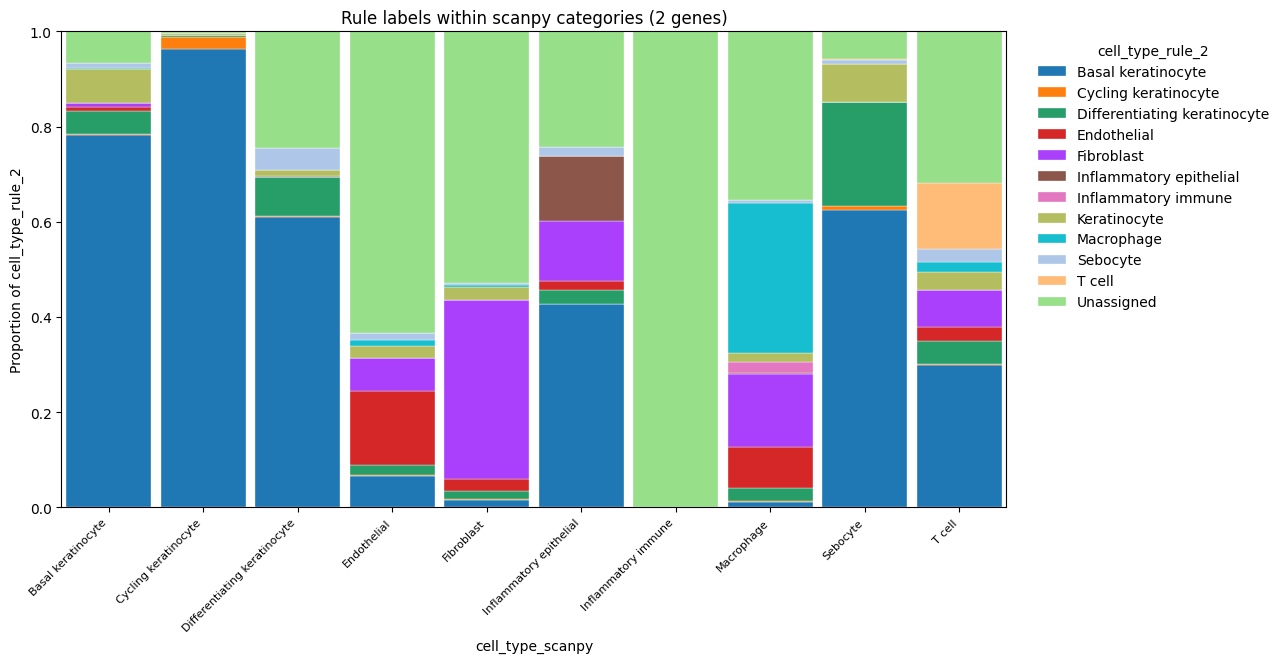

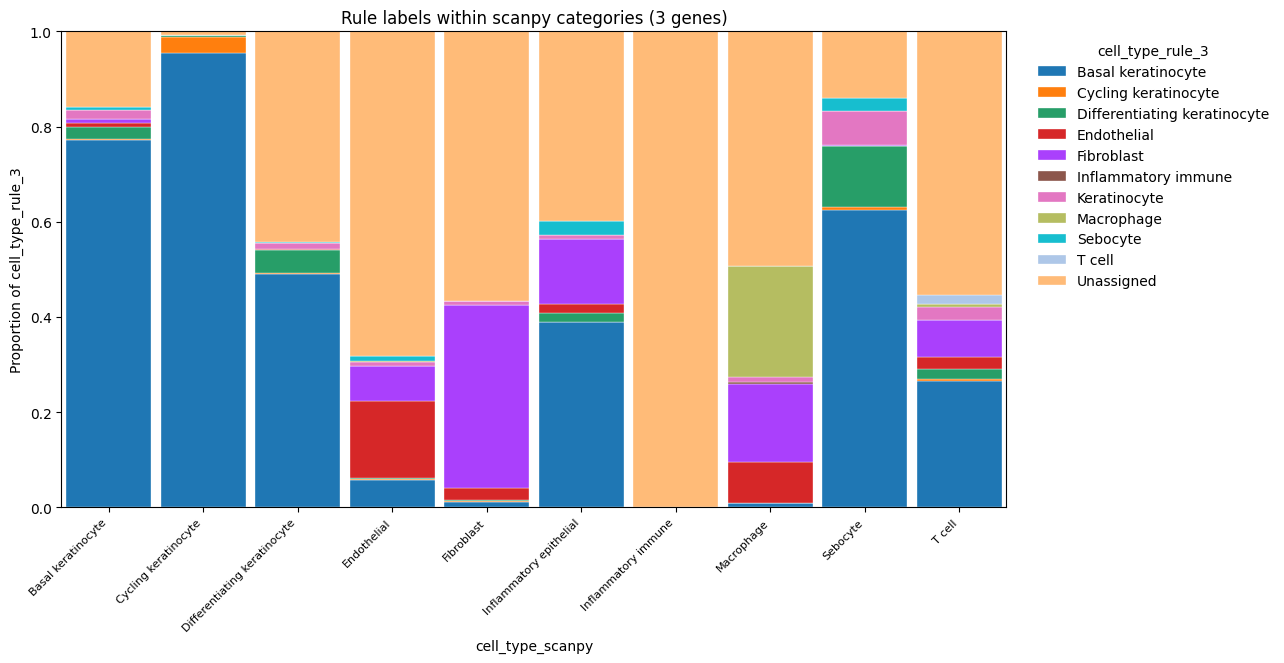

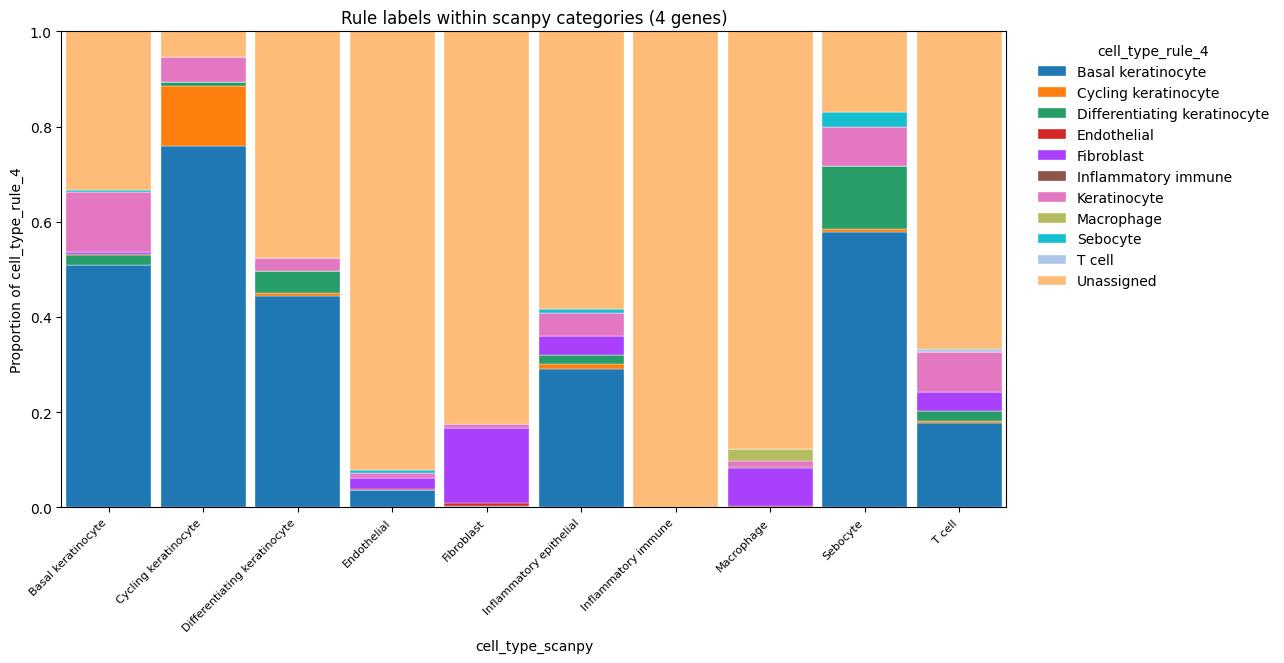

(cell_type_rule_4              Basal keratinocyte  Cycling keratinocyte  \
 cell_type_scanpy                                                         
 Basal keratinocyte                      0.508173              0.000726   
 Cycling keratinocyte                    0.759494              0.126582   
 Differentiating keratinocyte            0.444785              0.004601   
 Endothelial                             0.036585              0.000000   
 Fibroblast                              0.002273              0.000000   
 Inflammatory epithelial                 0.291262              0.009709   
 Inflammatory immune                     0.000000              0.000000   
 Macrophage                              0.000000              0.000000   
 Sebocyte                                0.578147              0.006916   
 T cell                                  0.177419              0.004608   
 
 cell_type_rule_4              Differentiating keratinocyte  Endothelial  \
 cell_type_scanpy     

In [98]:

custom_barplot(
    adata,
    var_1="cell_type_rule_2",
    var_2="cell_type_scanpy",
    plot_type="bar",
    cluster_bars=False,
    title=f"Rule labels within scanpy categories (2 genes)"
)
custom_barplot(
    adata,
    var_1="cell_type_rule_3",
    var_2="cell_type_scanpy",
    plot_type="bar",
    cluster_bars=False,
    title=f"Rule labels within scanpy categories (3 genes)"
)
custom_barplot(
    adata,
    var_1="cell_type_rule_4",
    var_2="cell_type_scanpy",
    plot_type="bar",
    cluster_bars=False,
    title=f"Rule labels within scanpy categories (4 genes)"
)


### **Comparing 2, 3 and 4 gene markers**

In [99]:
summary = pd.concat(
    [
        adata.obs["cell_type_rule_2"].value_counts().rename("2 markers"),
        adata.obs["cell_type_rule_3"].value_counts().rename("3 markers"),
        adata.obs["cell_type_rule_4"].value_counts().rename("4 markers"),
    ],
    axis=1
).fillna(0).astype(int)

display(summary)

,2 markers,3 markers,4 markers
Basal keratinocyte,3906,3675,2718
Unassigned,3108,4015,5774
Fibroblast,1348,1383,573
Differentiating keratinocyte,499,247,234
Keratinocyte,404,166,533
Endothelial,264,273,21
Macrophage,167,108,12
Sebocyte,141,48,46
T cell,63,9,2
Cycling keratinocyte,32,34,46


In [100]:
comparison = pd.DataFrame({
    "2 vs 3": adata.obs["cell_type_rule_2"].astype(str) != adata.obs["cell_type_rule_3"].astype(str),
    "3 vs 4": adata.obs["cell_type_rule_3"].astype(str) != adata.obs["cell_type_rule_4"].astype(str),
    "2 vs 4": adata.obs["cell_type_rule_2"].astype(str) != adata.obs["cell_type_rule_4"].astype(str),
})

print("Cells changing between marker sets:")
display(comparison.sum())

Cells changing between marker sets:


2 vs 3    1137
3 vs 4    2279
2 vs 4    3359
dtype: int64

In [101]:
print("Percentage of cells changing:")
display((comparison.mean() * 100).round(2))

Percentage of cells changing:


2 vs 3    11.42
3 vs 4    22.88
2 vs 4    33.72
dtype: float64

In [102]:
summary = pd.concat(
    [
        adata.obs["cell_type_rule_2"].value_counts().rename("2 markers"),
        adata.obs["cell_type_rule_3"].value_counts().rename("3 markers"),
        adata.obs["cell_type_rule_4"].value_counts().rename("4 markers"),
        adata.obs["cell_type_scanpy"].value_counts().rename("Scanpy"),
    ],
    axis=1
).fillna(0).astype(int)

display(summary)

,2 markers,3 markers,4 markers,Scanpy
Basal keratinocyte,3906,3675,2718,2753
Unassigned,3108,4015,5774,0
Fibroblast,1348,1383,573,3079
Differentiating keratinocyte,499,247,234,1304
Keratinocyte,404,166,533,0
Endothelial,264,273,21,738
Macrophage,167,108,12,433
Sebocyte,141,48,46,723
T cell,63,9,2,434
Cycling keratinocyte,32,34,46,237


In [37]:
print(adata.obs["region"].value_counts())

region
cell_circles    9960
Name: count, dtype: int64


In [103]:
percentage_2 = (
    adata.obs["cell_type_rule_2"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

percentage_3 = (
    adata.obs["cell_type_rule_3"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

percentage_4 = (
    adata.obs["cell_type_rule_4"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


In [104]:
percentage_summary = pd.concat([
    percentage_2.rename("2 markers (%)"),
    percentage_3.rename("3 markers (%)"),
    percentage_4.rename("4 markers (%)"),
    ],
    axis=1
).fillna(0)

percentage_summary = percentage_summary.reindex(
    [i for i in percentage_summary.index if i != "Unassigned"] + ["Unassigned"]
)

display(percentage_summary)

,2 markers (%),3 markers (%),4 markers (%)
Basal keratinocyte,39.22,36.90,27.29
Fibroblast,13.53,13.89,5.75
Differentiating keratinocyte,5.01,2.48,2.35
Keratinocyte,4.06,1.67,5.35
Endothelial,2.65,2.74,0.21
Macrophage,1.68,1.08,0.12
Sebocyte,1.42,0.48,0.46
T cell,0.63,0.09,0.02
Cycling keratinocyte,0.32,0.34,0.46
Inflammatory epithelial,0.17,0.00,0.00


In [105]:
# Remove Unassigned
assigned = adata.obs[
    ["cell_type_rule_2", "cell_type_rule_3", "cell_type_rule_4"]
].replace("Unassigned", np.nan)

# Get all cell types present across the three rules
cell_types = sorted(set(
    assigned["cell_type_rule_2"].dropna()
).union(
    assigned["cell_type_rule_3"].dropna()
).union(
    assigned["cell_type_rule_4"].dropna()
))

# Calculate percentage of assigned cells belonging to each cell type
percentage_assigned = pd.DataFrame(index=cell_types)

for n in [2, 3, 4]:
    counts = assigned[f"cell_type_rule_{n}"].value_counts()
    total_assigned = assigned[f"cell_type_rule_{n}"].notna().sum()
    
    percentage_assigned[f"{n} markers (%)"] = (
        counts / total_assigned * 100
    )

percentage_assigned = percentage_assigned.fillna(0)

# Calculate percentage change: 2 → 3 markers
percentage_assigned["Change 2 → 3 (%)"] = (
    (percentage_assigned["3 markers (%)"] -
     percentage_assigned["2 markers (%)"])
    / percentage_assigned["2 markers (%)"] * 100
).replace([np.inf, -np.inf], np.nan).round(2)

# Calculate percentage change: 3 → 4 markers
percentage_assigned["Change 3 → 4 (%)"] = (
    (percentage_assigned["4 markers (%)"] -
     percentage_assigned["3 markers (%)"])
    / percentage_assigned["3 markers (%)"] * 100
).replace([np.inf, -np.inf], np.nan).round(2)

# Keep only the percentage change columns
percentage_change = percentage_assigned[
    ["Change 2 → 3 (%)", "Change 3 → 4 (%)"]
]

display(percentage_change)


/tmp/ipykernel_602334/1308159526.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  ].replace("Unassigned", np.nan)


,Change 2 → 3 (%),Change 3 → 4 (%)
Basal keratinocyte,8.44,5.04
Cycling keratinocyte,22.46,92.15
Differentiating keratinocyte,-42.95,34.55
Endothelial,19.19,-89.08
Fibroblast,18.25,-41.16
Inflammatory epithelial,-100.00,NaN
Inflammatory immune,-79.04,-28.99
Keratinocyte,-52.64,356.01
Macrophage,-25.46,-84.22
Sebocyte,-60.76,36.10


### **Comparison**

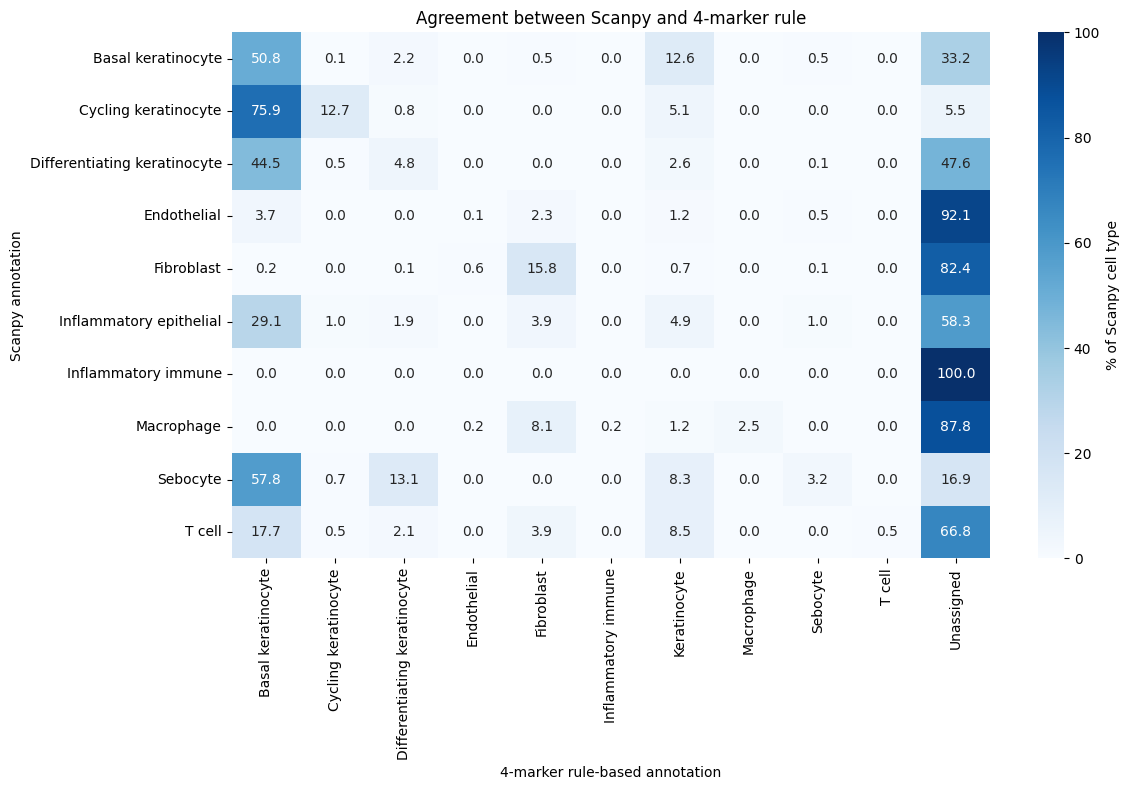

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compare Scanpy annotation with 4-marker rule
comparison = pd.crosstab(
    adata.obs["cell_type_scanpy"],
    adata.obs["cell_type_rule_4"]
)

# Convert to percentages within each Scanpy cell type
comparison_percent = comparison.div(
    comparison.sum(axis=1),
    axis=0
) * 100

plt.figure(figsize=(12, 8))

sns.heatmap(
    comparison_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "% of Scanpy cell type"}
)

plt.xlabel("4-marker rule-based annotation")
plt.ylabel("Scanpy annotation")
plt.title("Agreement between Scanpy and 4-marker rule")
plt.tight_layout()
plt.show()

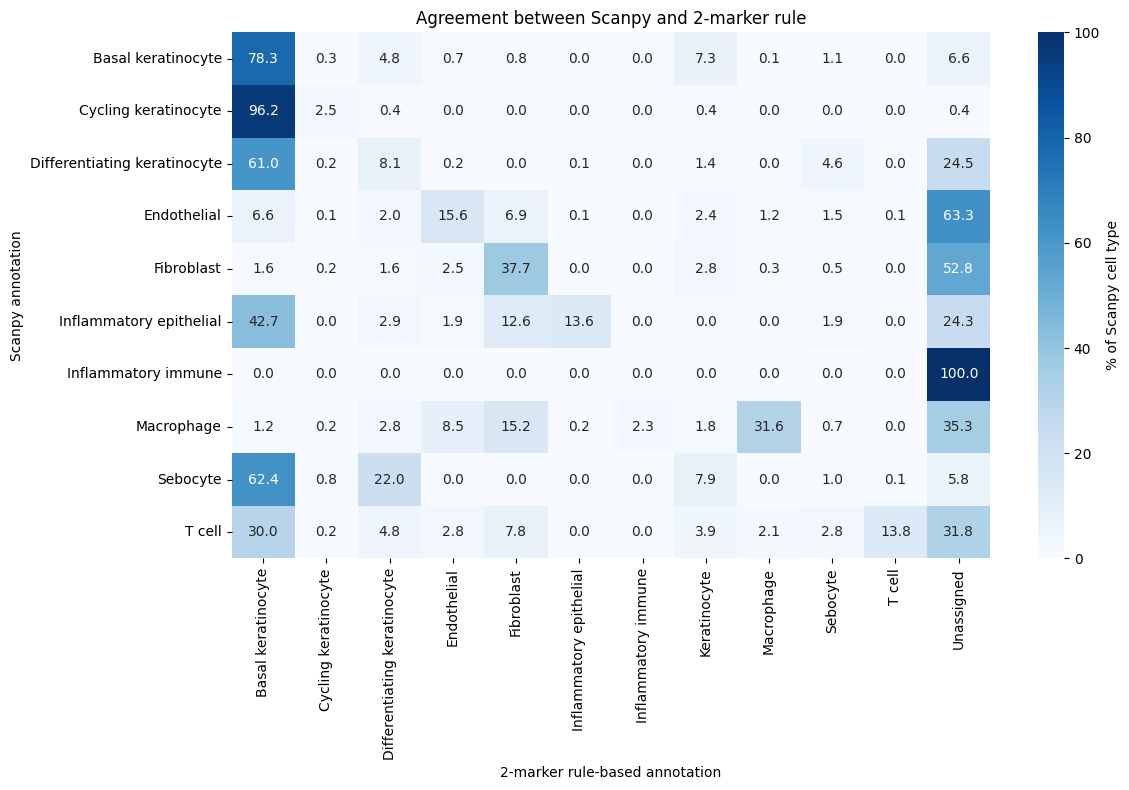

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compare Scanpy annotation with 2-marker rule
comparison = pd.crosstab(
    adata.obs["cell_type_scanpy"],
    adata.obs["cell_type_rule_2"]
)

# Convert to percentages within each Scanpy cell type
comparison_percent = comparison.div(
    comparison.sum(axis=1),
    axis=0
) * 100

plt.figure(figsize=(12, 8))

sns.heatmap(
    comparison_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "% of Scanpy cell type"}
)

plt.xlabel("2-marker rule-based annotation")
plt.ylabel("Scanpy annotation")
plt.title("Agreement between Scanpy and 2-marker rule")
plt.tight_layout()
plt.show()

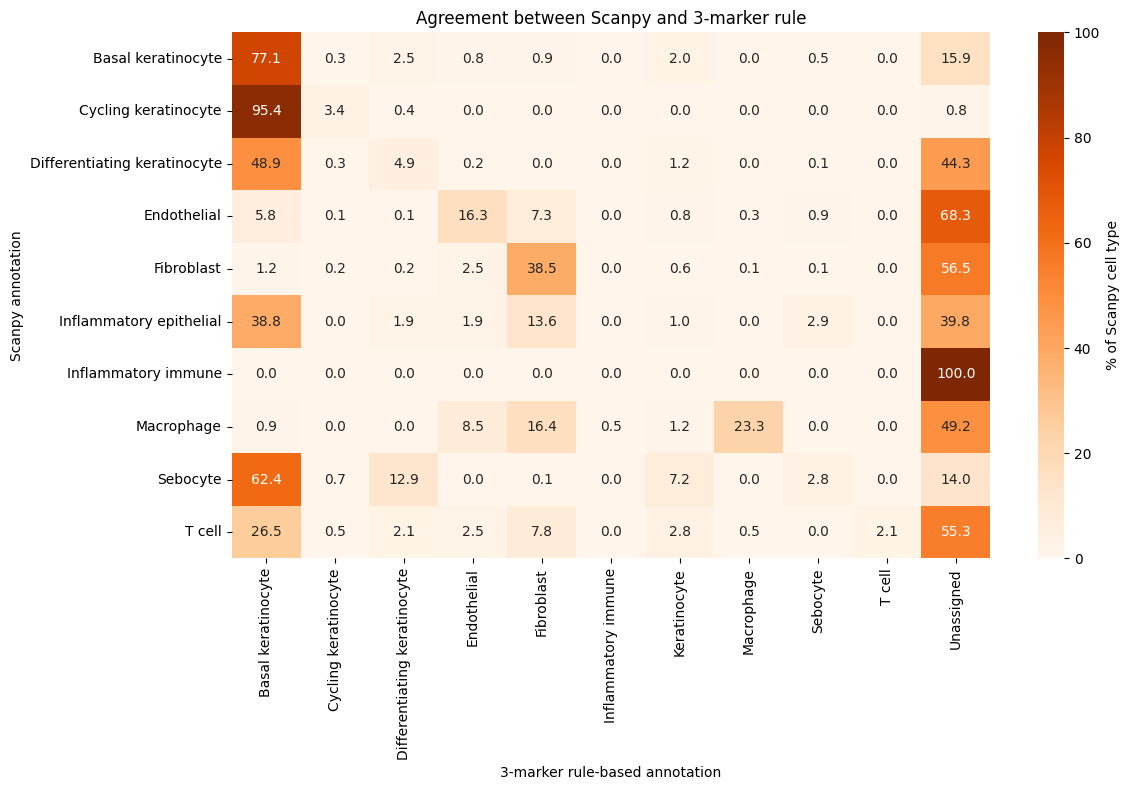

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compare Scanpy annotation with 3-marker rule
comparison = pd.crosstab(
    adata.obs["cell_type_scanpy"],
    adata.obs["cell_type_rule_3"]
)

# Convert to percentages within each Scanpy cell type
comparison_percent = comparison.div(
    comparison.sum(axis=1),
    axis=0
) * 100

plt.figure(figsize=(12, 8))

sns.heatmap(
    comparison_percent,
    annot=True,
    fmt=".1f",
    cmap="Oranges",
    cbar_kws={"label": "% of Scanpy cell type"}
)

plt.xlabel("3-marker rule-based annotation")
plt.ylabel("Scanpy annotation")
plt.title("Agreement between Scanpy and 3-marker rule")
plt.tight_layout()
plt.show()

In [109]:
print(adata.obsm.keys())

KeysView(AxisArrays with keys: spatial, X_umap, X_pca)


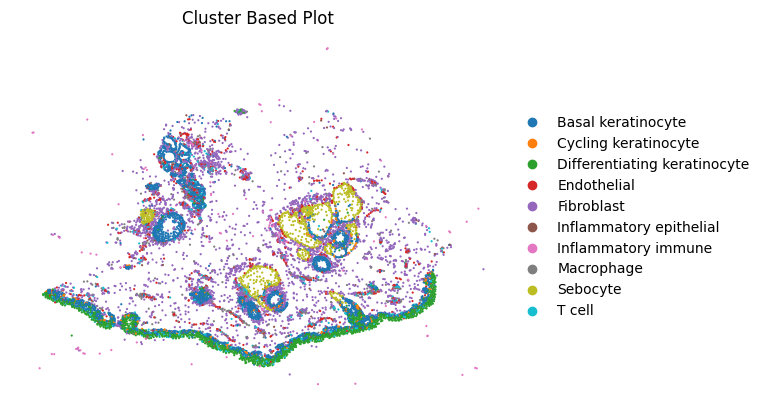

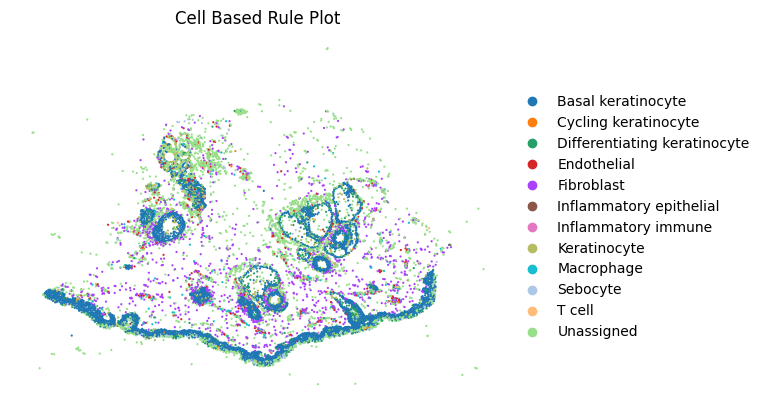

In [110]:
sc.pl.embedding(
    adata,
    basis="spatial",
    color="cell_type_scanpy",
    title="Cluster Based Plot",
    frameon=False,
    size=10
)

sc.pl.embedding(
    adata,
    basis="spatial",
    color="cell_type_rule_2",
    title="Cell Based Rule Plot",
    frameon=False,
    size=10
)


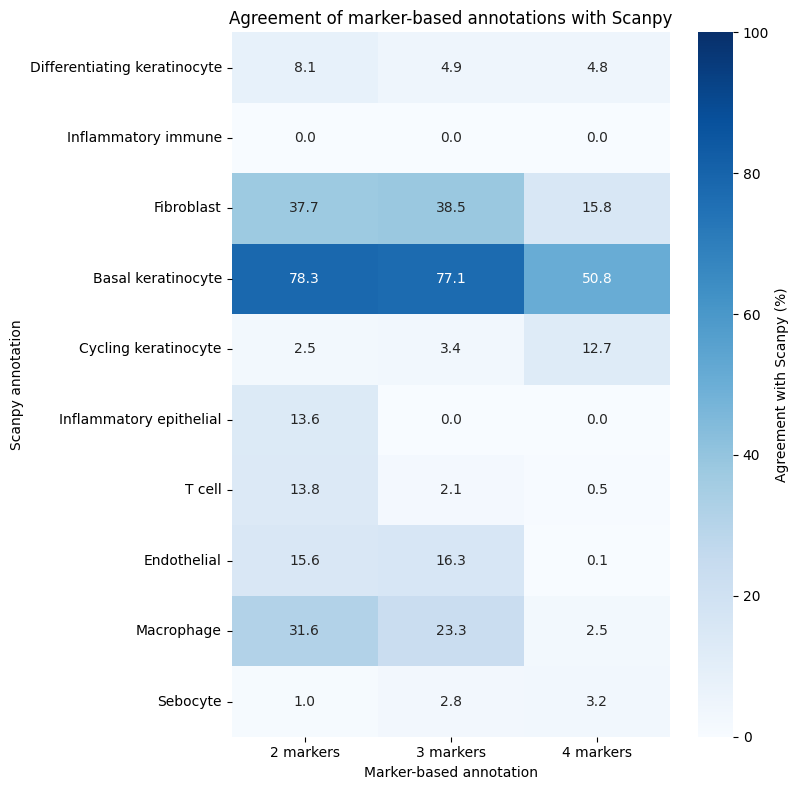

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate agreement with Scanpy for each cell type
heatmap_data = pd.DataFrame(index=adata.obs["cell_type_scanpy"].unique())

for method, column in [
    ("2 markers", "cell_type_rule_2"),
    ("3 markers", "cell_type_rule_3"),
    ("4 markers", "cell_type_rule_4")
]:
    heatmap_data[method] = (
        adata.obs.groupby("cell_type_scanpy", observed=True)[column]
        .apply(lambda x: (x == x.name).mean() * 100)
    )

heatmap_data = heatmap_data.round(1)

# Plot
plt.figure(figsize=(8, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Agreement with Scanpy (%)"}
)

plt.xlabel("Marker-based annotation")
plt.ylabel("Scanpy annotation")
plt.title("Agreement of marker-based annotations with Scanpy")
plt.tight_layout()
plt.show()

In [113]:
comparison = adata.obs[
    ["cell_type_rule_2", "cell_type_rule_3", "cell_type_rule_4"]
].astype(str)

comparison_counts = (
    comparison
    .value_counts()
    .reset_index(name="Number of cells")
)


pd.set_option("display.max_rows", None)



In [114]:
comparison = adata.obs[
    ["cell_type_rule_2", "cell_type_rule_3", "cell_type_rule_4"]
].astype(str)

summary = pd.DataFrame({
    "2 → 3 (%)": [
        (comparison["cell_type_rule_2"] == comparison["cell_type_rule_3"]).mean() * 100,
        (
            (comparison["cell_type_rule_2"] != "Unassigned") &
            (comparison["cell_type_rule_3"] == "Unassigned")
        ).mean() * 100,
        (
            (comparison["cell_type_rule_2"] != comparison["cell_type_rule_3"]) &
            (comparison["cell_type_rule_2"] != "Unassigned") &
            (comparison["cell_type_rule_3"] != "Unassigned")
        ).mean() * 100
    ],
    "3 → 4 (%)": [
        (comparison["cell_type_rule_3"] == comparison["cell_type_rule_4"]).mean() * 100,
        (
            (comparison["cell_type_rule_3"] != "Unassigned") &
            (comparison["cell_type_rule_4"] == "Unassigned")
        ).mean() * 100,
        (
            (comparison["cell_type_rule_3"] != comparison["cell_type_rule_4"]) &
            (comparison["cell_type_rule_3"] != "Unassigned") &
            (comparison["cell_type_rule_4"] != "Unassigned")
        ).mean() * 100
    ]
}, index=[
    "Stayed the same",
    "Became Unassigned",
    "Changed cell type"
]).round(2)

display(summary)

,2 → 3 (%),3 → 4 (%)
Stayed the same,88.58,77.12
Became Unassigned,9.11,17.66
Changed cell type,2.31,5.22


### **False Discovery Rate**

In [115]:
from __future__ import annotations

from typing import Literal

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [116]:
def _micro_precision(fdr_df: pd.DataFrame) -> float:
    """Aggregate precision: sum(TP) / sum(n_predicted)."""
    if fdr_df.empty:
        return float("nan")
    tp = fdr_df["TP"].sum()
    n_pred = fdr_df["n_predicted"].sum()
    return float(tp / n_pred) if n_pred else float("nan")


def celltype_fdr(
    adata: ad.AnnData,
    ref_col: str,
    query_col: str,
    *,
    exclude_query_labels: set[str] | None = None,
) -> pd.DataFrame:
    """Per query-predicted label: TP/FP vs reference (FDR = FP / (TP+FP))."""
    missing = [c for c in (ref_col, query_col) if c not in adata.obs.columns]
    if missing:
        raise KeyError(f"Missing adata.obs columns: {missing}")

    exclude_query_labels = exclude_query_labels or set()
    ref = adata.obs[ref_col].astype(str)
    query = adata.obs[query_col].astype(str)

    results: list[dict] = []
    for cell_type in sorted(query.dropna().unique()):
        if cell_type in exclude_query_labels:
            continue
        truth_pos = ref == cell_type
        pred_pos = query == cell_type
        tp = int((truth_pos & pred_pos).sum())
        fp = int((~truth_pos & pred_pos).sum())
        n_predicted = tp + fp
        fdr = fp / n_predicted if n_predicted > 0 else float("nan")
        results.append(
            {
                "cell_type": cell_type,
                "TP": tp,
                "FP": fp,
                "n_predicted": n_predicted,
                "FDR": fdr,
                "precision": 1 - fdr if n_predicted > 0 else float("nan"),
            }
        )

    return (
        pd.DataFrame(results)
        .sort_values("FDR", na_position="last")
        .reset_index(drop=True)
    )

In [117]:
def plot_celltype_fdr(
    fdr_df: pd.DataFrame,
    *,
    ref_name: str,
    query_name: str,
    metric: Literal["fdr", "precision"] = "precision",
    ax=None,
    figsize: tuple[float, float] | None = None,
    color: str = "#2a9d8f",
):
    """Horizontal bar chart of per-type FDR or precision for the query vs reference."""
    if fdr_df.empty:
        raise ValueError("fdr_df is empty; nothing to plot")

    if metric == "precision":
        plot_df = fdr_df.sort_values("precision", ascending=True, na_position="first")
        values = plot_df["precision"]
        xlabel = "Precision (1 − FDR)"
        title = f"{query_name}: precision vs {ref_name} reference"
        ref_line = 0.5
    elif metric == "fdr":
        plot_df = fdr_df.sort_values("FDR", ascending=True, na_position="first")
        values = plot_df["FDR"]
        xlabel = "FDR"
        title = f"{query_name}: FDR vs {ref_name} reference"
        ref_line = None
    else:
        raise ValueError(f"metric must be 'fdr' or 'precision', got {metric!r}")

    n_types = len(plot_df)
    if figsize is None:
        figsize = (10, max(4, 0.45 * n_types))

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    y = np.arange(n_types)
    ax.barh(y, values, color=color, height=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["cell_type"])
    ax.set_xlim(0, 1.05)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    if ref_line is not None:
        ax.axvline(ref_line, color="gray", linestyle=":", linewidth=0.8)
    plt.tight_layout()
    return ax, plot_df


In [118]:
print(adata.obs.columns.tolist())

['cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'leiden', 'cell_type_scanpy', 'cell_type_rule', 'cell_type_rule_2', 'cell_type_rule_3', 'cell_type_rule_4']


Loaded 9,960 cells
Micro precision (2 marker rule-based vs scanpy): 0.549
Macro precision (mean per predicted type): 0.445


,cell_type,TP,FP,n_predicted,FDR,precision_vs_scanpy
0,T cell,60,3,63,0.047619,0.952381
1,Fibroblast,1161,187,1348,0.138724,0.861276
2,Inflammatory epithelial,14,3,17,0.176471,0.823529
3,Macrophage,137,30,167,0.179641,0.820359
4,Basal keratinocyte,2155,1751,3906,0.448285,0.551715
5,Endothelial,115,149,264,0.564394,0.435606
6,Differentiating keratinocyte,105,394,499,0.789579,0.210421
7,Cycling keratinocyte,6,26,32,0.812500,0.187500
8,Sebocyte,7,134,141,0.950355,0.049645
9,Inflammatory immune,0,11,11,1.000000,0.000000


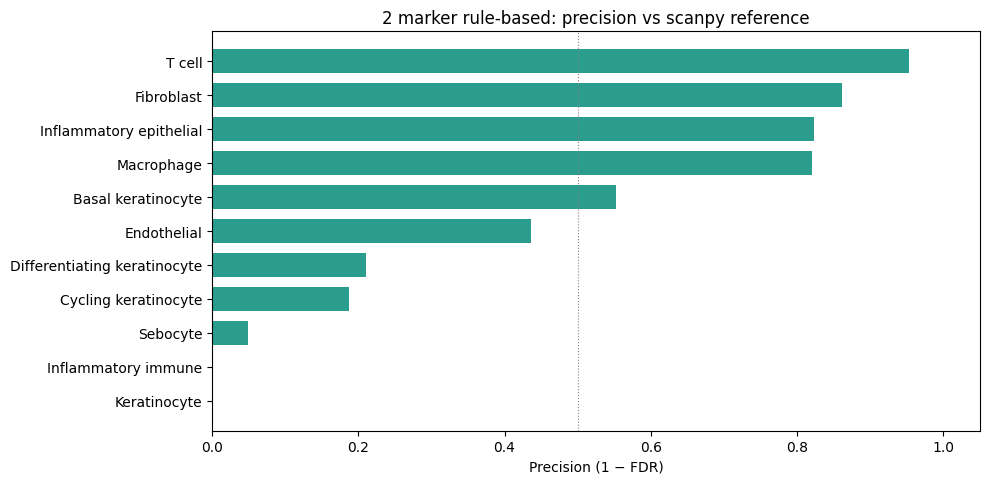

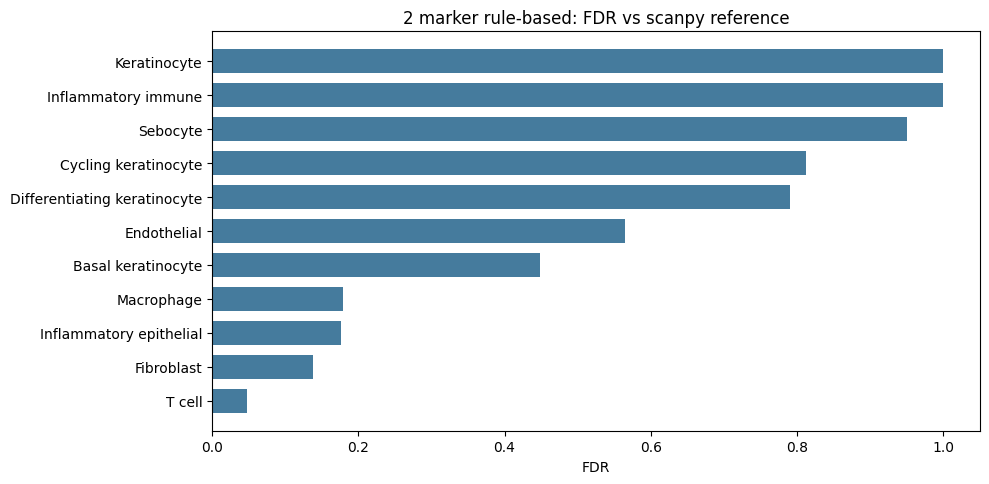

In [120]:
from IPython.display import display


print(f"Loaded {adata.n_obs:,} cells")

# --- configure ---

REF_COL = "cell_type_scanpy"
QUERY_COL = "cell_type_rule_2"

EXCLUDE_QUERY = {"Unassigned", "Ambiguous"}

REF_NAME = "scanpy"
QUERY_NAME = "2 marker rule-based"

# Check that the annotation columns exist
missing_cols = [
    c for c in (REF_COL, QUERY_COL)
    if c not in adata.obs.columns
]

if missing_cols:
    raise KeyError(
        f"Missing adata.obs columns: {missing_cols}"
    )

# Calculate FDR / precision
fdr_df = celltype_fdr(
    adata,
    REF_COL,
    QUERY_COL,
    exclude_query_labels=EXCLUDE_QUERY,
)

# Overall precision
micro = _micro_precision(fdr_df)

macro = (
    float(fdr_df["precision"].mean())
    if len(fdr_df)
    else float("nan")
)

print(f"Micro precision ({QUERY_NAME} vs {REF_NAME}): {micro:.3f}")
print(f"Macro precision (mean per predicted type): {macro:.3f}")

display(
    fdr_df.rename(
        columns={
            "precision": f"precision_vs_{REF_NAME}"
        }
    )
)

# Plot precision
n_types = max(len(fdr_df), 1)
figsize = (10, max(4, 0.45 * n_types))

plot_celltype_fdr(
    fdr_df,
    ref_name=REF_NAME,
    query_name=QUERY_NAME,
    metric="precision",
    figsize=figsize,
)

plt.show()

# Plot FDR
plot_celltype_fdr(
    fdr_df,
    ref_name=REF_NAME,
    query_name=QUERY_NAME,
    metric="fdr",
    figsize=figsize,
    color="#457b9d",
)

plt.show()

In [72]:
print(adata.obs.columns.tolist())

['cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region']


In [121]:
def _assert_fdr_row(df, cell_type, tp, fp):
    row = df.loc[df["cell_type"] == cell_type].iloc[0]
    assert row["TP"] == tp and row["FP"] == fp, (cell_type, row.to_dict())
    n = tp + fp
    assert abs(row["FDR"] - fp / n) < 1e-9
    assert abs(row["precision"] - tp / n) < 1e-9


obs = pd.DataFrame(
    {
        "ref": ["A", "A", "A", "B", "B", "C"],
        "query": ["A", "A", "B", "B", "B", "C"],
    }
)
tiny = ad.AnnData(np.zeros((6, 1)), obs=obs)

out = celltype_fdr(tiny, "ref", "query")
_assert_fdr_row(out, "A", tp=2, fp=0)
_assert_fdr_row(out, "B", tp=2, fp=1)
_assert_fdr_row(out, "C", tp=1, fp=0)
print("Synthetic celltype_fdr: OK")
print(out.to_string(index=False))

Synthetic celltype_fdr: OK
cell_type  TP  FP  n_predicted      FDR  precision
        A   2   0            2 0.000000   1.000000
        C   1   0            1 0.000000   1.000000
        B   2   1            3 0.333333   0.666667


/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
